In [7]:
import pandas as pd
import numpy as np
df = pd.read_excel(r"C:\Users\mario.lira\OneDrive - MEDIATORIE ADMINISTRADORA DE BENEFICIOS LTDA\Aplicativos\Área de Trabalho\Nova pasta (3)\Efetivação de Janeiro - 14.07 (1) (1).xlsx")

In [8]:
df['data_total'] = (df['Data do envio informativo']-df['Vigência Inicio']).dt.days
df['Prazo'] = np.where(df['data_total']<=4,'Dentro','Fora')


In [9]:
odonto = {'MASTER I SINDILIMPE SAMP ODONTO',
'Essencial Unimed Odonto Até 99 vidas',
'PLENO UNIMED ODONTO',
'Pleno Unimed Odonto Até 29 vidas',
'Plus Doc Unimed Odonto Acima 100 vidas',
'BÁSICO ROL EMP SAMP ODONTO',
'4971 - ESSENCIAL II DOC EMP SEMPRE',
'MASTER I ROL + DOC + PLACA SAMP ODONTO',
'MASTER I ROL + DOC SAMP ODONTO',
'4658 - ESSENCIAL II EMP SEMPRE',
'ESSENCIAL UNIMED ODONTO',
'ESSENCIAL PLUS DOC UNIMED ODONTO',
'ESSENCIAL PLUS UNIMED ODONTO',
'MASTER I DOC SINTRAFARMA SAMP ODONTO',
'ESSENCIAL FR UNIMED ODONTO',
'Executivo Odonto AESP',
'4658 - ESSENCIAL II EMP SEMPRE GRUPO 01',
'Odonto - Essencial Emp Odonto CB',
'Plus Doc Unimed Odonto Até 29 vidas',
'Plus Unimed Odonto Até 99 vidas',
'4658 - ESSENCIAL II EMP 100 DESCONTO',
'MASTER I SINDUSCON SAMP ODONTO',
'Pleno Adesao Unimed Odonto',
'4658 - ESSENCIAL II EMP SEMPRE ATE 29',
'Plus Unimed Odonto Acima 100 vidas',
'4971 - ESSENCIAL II DOC EMP SEMPRE FARMA',
'MASTER I DOC SINTRAMASSAS SAMP ODONTO',
'MASTER I SINTRAMASSAS SAMP ODONTO',
'Essencial Plus Doc Adesao Unimed Odonto',
'Plus Doc Unimed Odonto 30 a 99 vidas',
'Pleno Unimed Odonto 30 a 99 vidas',
'Essencial Adesao Unimed Odonto',
'3 - STANDARD - AESP ODONTO',
'MASTER I SAMP ODONTO 30 OU + VIDAS',
'Essencial Plus Adesao Unimed Odonto',
}

In [10]:
planos_odonto = df[df['Descrição do produto'].isin(odonto)]
planos_odonto['competencia'] = planos_odonto['Vigência Inicio'].dt.month.astype(str).str.zfill(2) + '/' + planos_odonto['Vigência Inicio'].dt.year.astype(str)

C:\Users\mario.lira\AppData\Local\Temp\ipykernel_11960\1365770888.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  planos_odonto['competencia'] = planos_odonto['Vigência Inicio'].dt.month.astype(str).str.zfill(2) + '/' + planos_odonto['Vigência Inicio'].dt.year.astype(str)


In [11]:
planos_odonto_dentro = planos_odonto[planos_odonto['Prazo']=='Dentro']
planos_odonto_fora = planos_odonto[planos_odonto['Prazo']=='Fora']

In [12]:
planos_odonto_dentro_g = planos_odonto_dentro.groupby('competencia')['Prazo'].count().reset_index()
planos_odonto_fora_g = planos_odonto_fora.groupby('competencia')['Prazo'].count().reset_index()

In [13]:
planos_odonto_fora_g
tabela = pd.merge(planos_odonto_fora_g,planos_odonto_dentro_g,how='outer', on='competencia').fillna(0)


In [14]:
colunas = ['Comp', 'Fora', 'Dentro']
tabela.columns = colunas
tabela['Total'] = tabela['Fora'] + tabela['Dentro']
tabela['Percentual_Fora'] = (tabela['Fora']/tabela['Total']*100).round(2)
tabela['Percentual_Dentro'] = (tabela['Dentro']/tabela['Total']*100).round(2)

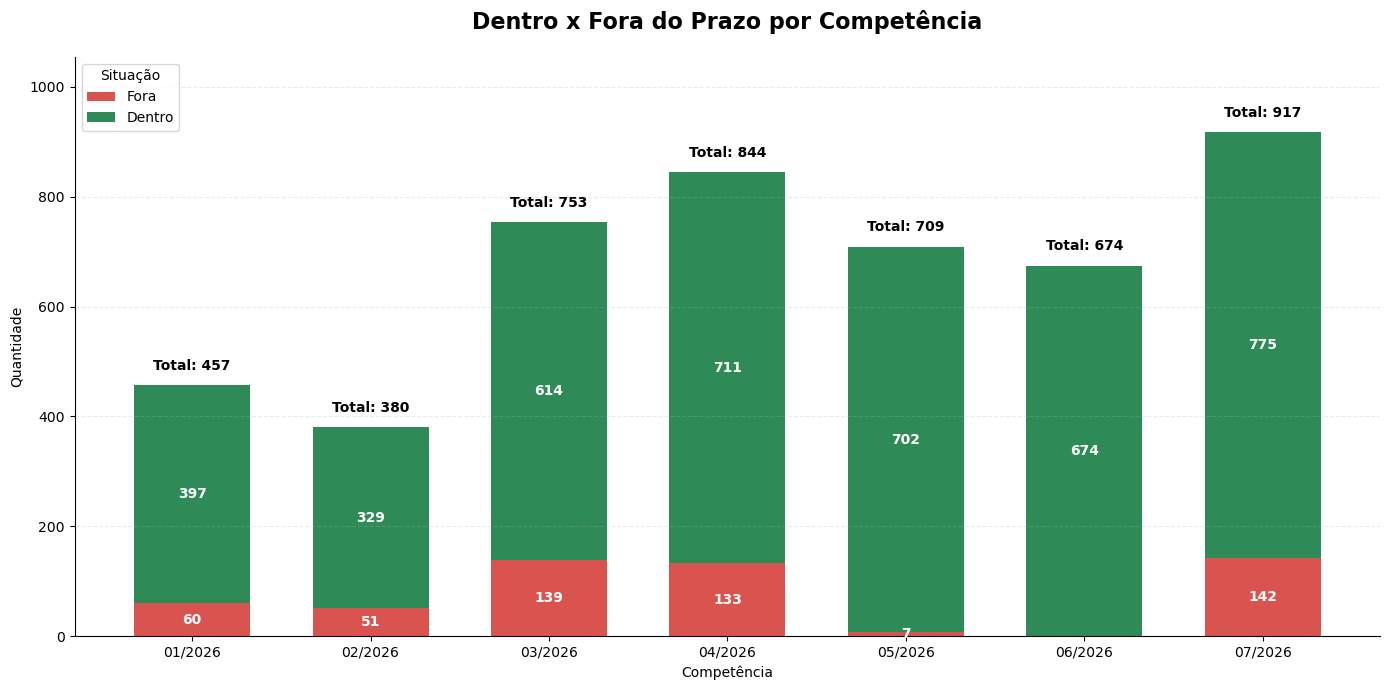

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Sua tabela original
dados = tabela.copy()


# =========================================================
# TRATAMENTO
# =========================================================

dados["Ordem"] = pd.to_datetime(
    dados["Comp"],
    format="%m/%Y",
    errors="coerce"
)

for coluna in ["Fora", "Dentro", "Total"]:
    dados[coluna] = pd.to_numeric(
        dados[coluna],
        errors="coerce"
    )

dados = (
    dados
    .dropna(subset=["Ordem", "Fora", "Dentro", "Total"])
    .sort_values("Ordem")
    .reset_index(drop=True)
)


# =========================================================
# DADOS DO GRÁFICO
# =========================================================

# Meses exibidos embaixo das barras
competencias = dados["Comp"].to_numpy()

# Essa variável é criada aqui.
# Ela não precisa existir como coluna na tabela.
situacoes = {
    "Fora": dados["Fora"].to_numpy(),
    "Dentro": dados["Dentro"].to_numpy()
}

cores = {
    "Fora": "#D9534F",
    "Dentro": "#2E8B57"
}


# =========================================================
# GRÁFICO
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)

largura = 0.65

# Um zero para cada competência
base = np.zeros(
    len(dados),
    dtype=float
)


# =========================================================
# BARRAS EMPILHADAS
# =========================================================

for situacao, valores in situacoes.items():

    barras = ax.bar(
        competencias,
        valores,
        width=largura,
        bottom=base,
        label=situacao,
        color=cores[situacao]
    )

    rotulos = [
        f"{int(valor)}"
        if valor > 0
        else ""
        for valor in valores
    ]

    ax.bar_label(
        barras,
        labels=rotulos,
        label_type="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

    # A próxima parte começa onde a anterior terminou
    base = base + valores


# =========================================================
# TOTAL ACIMA DE CADA BARRA
# =========================================================

maior_total = dados["Total"].max()

for posicao, total in enumerate(dados["Total"]):

    ax.text(
        posicao,
        total + maior_total * 0.025,
        f"Total: {int(total)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# =========================================================
# APARÊNCIA
# =========================================================

ax.set_title(
    "Dentro x Fora do Prazo por Competência",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Competência")
ax.set_ylabel("Quantidade")

ax.set_ylim(
    0,
    maior_total * 1.15
)

ax.legend(
    title="Situação",
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

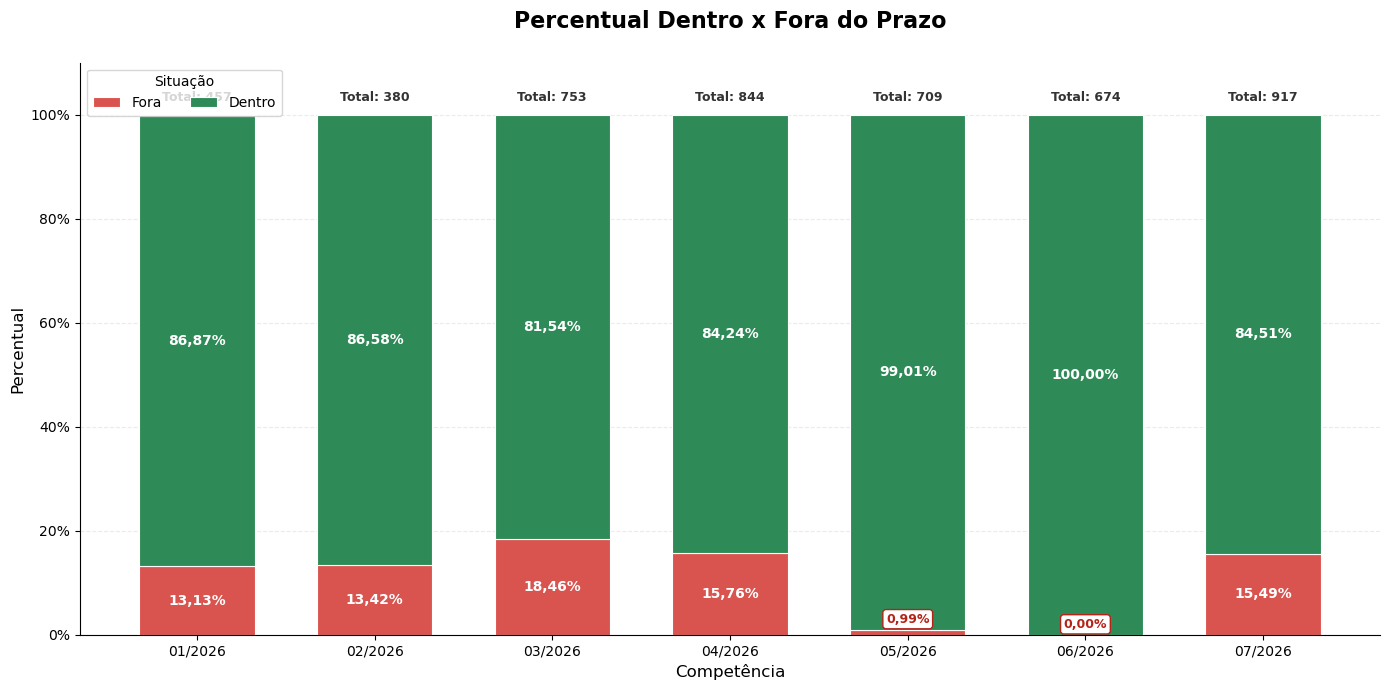

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# =========================================================
# PREPARAÇÃO DA TABELA
# =========================================================

dados = tabela.copy()

dados["Ordem"] = pd.to_datetime(
    dados["Comp"],
    format="%m/%Y",
    errors="coerce"
)

colunas_numericas = [
    "Percentual_Fora",
    "Percentual_Dentro",
    "Total"
]

for coluna in colunas_numericas:
    dados[coluna] = pd.to_numeric(
        dados[coluna],
        errors="coerce"
    )

dados = (
    dados
    .dropna(
        subset=[
            "Ordem",
            "Percentual_Fora",
            "Percentual_Dentro",
            "Total"
        ]
    )
    .sort_values("Ordem")
    .reset_index(drop=True)
)


# =========================================================
# DADOS DO GRÁFICO
# =========================================================

competencias = dados["Comp"].to_numpy()

percentuais = {
    "Fora": dados["Percentual_Fora"].to_numpy(),
    "Dentro": dados["Percentual_Dentro"].to_numpy()
}

cores = {
    "Fora": "#D9534F",
    "Dentro": "#2E8B57"
}


# =========================================================
# CRIAÇÃO DO GRÁFICO
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)

largura = 0.65
base = np.zeros(len(dados))


# =========================================================
# BARRAS EMPILHADAS
# =========================================================

for situacao, valores in percentuais.items():

    ax.bar(
        competencias,
        valores,
        width=largura,
        bottom=base,
        label=situacao,
        color=cores[situacao],
        edgecolor="white",
        linewidth=0.8
    )

    base = base + valores


# =========================================================
# RÓTULOS DOS PERCENTUAIS
# =========================================================

for posicao, linha in dados.iterrows():

    percentual_fora = linha["Percentual_Fora"]
    percentual_dentro = linha["Percentual_Dentro"]

    rotulo_fora = (
        f"{percentual_fora:.2f}%"
        .replace(".", ",")
    )

    rotulo_dentro = (
        f"{percentual_dentro:.2f}%"
        .replace(".", ",")
    )

    # Percentual fora
    if percentual_fora >= 8:

        # Quando há espaço, coloca dentro da parte vermelha
        ax.text(
            posicao,
            percentual_fora / 2,
            rotulo_fora,
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

    else:

        # Quando a faixa é pequena, coloca um rótulo destacado
        ax.text(
            posicao,
            percentual_fora + 2,
            rotulo_fora,
            ha="center",
            va="center",
            color="#B42318",
            fontsize=9,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                edgecolor="#B42318",
                boxstyle="round,pad=0.25"
            )
        )

    # Percentual dentro
    ax.text(
        posicao,
        percentual_fora + percentual_dentro / 2,
        rotulo_dentro,
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

    # Total de registros acima da barra
    ax.text(
        posicao,
        102,
        f"Total: {int(linha['Total'])}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#333333"
    )


# =========================================================
# APARÊNCIA
# =========================================================

ax.set_title(
    "Percentual Dentro x Fora do Prazo",
    fontsize=16,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "Competência",
    fontsize=12
)

ax.set_ylabel(
    "Percentual",
    fontsize=12
)

# Todas as barras terminam em 100%
ax.set_ylim(0, 110)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

ax.set_yticks(
    np.arange(0, 101, 20)
)

ax.legend(
    title="Situação",
    loc="upper left",
    ncol=2
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()